### Scoring Parameter

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as mlt

In [2]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

heart_disease = pd.read_csv("heart-disease.csv")

X = heart_disease.drop("target", axis = 1)
y = heart_disease["target"]

model = RandomForestClassifier()

In [3]:
cv_score = cross_val_score(model, X, y)
cv_score

array([0.85245902, 0.86885246, 0.81967213, 0.8       , 0.75      ])

In [4]:
cv_score_mean = np.mean(cv_score)
cv_score_mean

np.float64(0.8181967213114755)

In [5]:
cv_score_accuracy = cross_val_score(model, X, y, scoring=None)
cv_score

array([0.85245902, 0.86885246, 0.81967213, 0.8       , 0.75      ])

In [6]:
cv_score_precision = cross_val_score(model, X, y, scoring="precision")
cv_score

array([0.85245902, 0.86885246, 0.81967213, 0.8       , 0.75      ])

In [7]:
cv_score_precision = cross_val_score(model, X, y, scoring="recall")
cv_score

array([0.85245902, 0.86885246, 0.81967213, 0.8       , 0.75      ])

In [8]:
cv_score_precision = cross_val_score(model, X, y, scoring="f1")
cv_score

array([0.85245902, 0.86885246, 0.81967213, 0.8       , 0.75      ])

### Scoring for Regression
* R^2 is the default (scoring=None)
* neg_mean_absolute_error
* neg_mean_squared_error

## Metric Functions

In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

np.random.seed(10)

X= heart_disease.drop("target", axis=1)
y= heart_disease["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()

model.fit(X_train, y_train)

y_preds = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_preds)*100:.2f}%")
print(f"Accuracy: {precision_score(y_test, y_preds)}")
print(f"Accuracy: {recall_score(y_test, y_preds)}")
print(f"Accuracy: {f1_score(y_test, y_preds)}")

Accuracy: 78.69%
Accuracy: 0.7241379310344828
Accuracy: 0.8076923076923077
Accuracy: 0.7636363636363637


## Metric functions for Regression
* from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Improving a Model

* Baseline Model, and baseline prediction

Improving the model
* from the perspective of data
*  more data
*  improving data

Improving from the model's perspective
* is there a better model to use
* improving the current model (hyperparameters)

Hyperparameter tuning
* Manual tuning
* randomly with RandomSearchCV
* Exhaustively with GridSearchCV

In [10]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.get_params()


{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

### Tuning hapyerparameters Manually

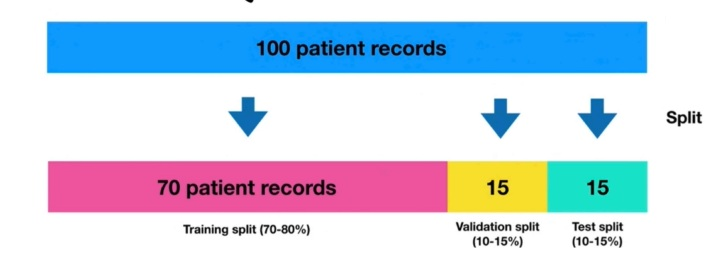

In [11]:
from IPython.display import Image, display
display(Image(filename='training.jpg'))

'max_depth'
'max_features'
'min_samples_leaf'
'min_samples_split'
'n_estimators'

In [12]:
def evaluate_preds(y_true, y_preds):
    accuracy = accuracy_score(y_true, y_preds)
    precision= precision_score(y_true, y_preds)
    f1 = f1_score(y_true, y_preds)
    recall = recall_score(y_true, y_preds)

    metric_dictionary ={"accuracy": round(accuracy, 2),
                       "precision": round(precision, 2),
                       "recall": round(recall, 2),
                       "f1": round(f1, 2)}

    print(f"accuracy: {accuracy * 100:.2f}%")
    print(f"Precision: {precision: .2f}")
    print(f"recall: {recall: .2f}")
    print(f"f1: {f1: .2f}")

    return metric_dictionary

In [13]:
# Splitting the data.

from sklearn.ensemble import RandomForestClassifier
np.random.seed(10)
heart_disease = heart_disease.sample(frac=1)

X = heart_disease.drop("target", axis=1)
y= heart_disease["target"]

train_split = round(0.7 * len(heart_disease))
valid_split = round(train_split+0.15 * len(heart_disease))

# train, validation, test splits
X_train, y_train = X[:train_split], y[:train_split]
X_valid, y_valid = X[train_split:valid_split], y[train_split: valid_split]
X_test, y_test = X[valid_split:], y[valid_split:]

model = RandomForestClassifier()

model.fit(X_train, y_train)

y_preds=model.predict(X_valid)

baseline_metrics = evaluate_preds(y_valid, y_preds)

baseline_metrics

accuracy: 84.44%
Precision:  0.91
recall:  0.81
f1:  0.86


{'accuracy': 0.84, 'precision': 0.91, 'recall': 0.81, 'f1': 0.86}

In [14]:
# tuning n_estimators

model2 = RandomForestClassifier(n_estimators=209)

model2.fit(X_train, y_train)

y_preds2 = model2.predict(X_valid)

model2_metrics = evaluate_preds(y_valid, y_preds2)

accuracy: 80.00%
Precision:  0.87
recall:  0.77
f1:  0.82


In [15]:
model2 = RandomForestClassifier(n_estimators=129, 
                               max_depth=20)

model2.fit(X_train, y_train)

y_preds2 = model2.predict(X_valid)

model2_metrics = evaluate_preds(y_valid, y_preds2)

accuracy: 82.22%
Precision:  0.88
recall:  0.81
f1:  0.84


### Tuning using RandomSearch CV

In [16]:
from sklearn.model_selection import RandomizedSearchCV

grid = {"n_estimators": [100,200,250,300,500],
        "max_depth": [None, 5, 10,15,20],
        "max_features": ["auto", "sqrt"],
        "min_samples_split": [2,4,6,8],
        "min_samples_leaf": [1,2,4]}
np.random.seed(23)

X = heart_disease.drop("target", axis = 1)
y = heart_disease["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier(n_jobs=1) #None, 1, 2, ..., -1
rs_model = RandomizedSearchCV(estimator=model,
                             param_distributions=grid,
                             n_iter=10,
                             cv=5,
                             verbose=2)

#fit the randomized search cv

rs_model.fit(X_train, y_train);

        

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END max_depth=5, max_features=auto, min_samples_leaf=4, min_samples_split=8, n_estimators=300; total time=   0.0s
[CV] END max_depth=5, max_features=auto, min_samples_leaf=4, min_samples_split=8, n_estimators=300; total time=   0.0s
[CV] END max_depth=5, max_features=auto, min_samples_leaf=4, min_samples_split=8, n_estimators=300; total time=   0.0s
[CV] END max_depth=5, max_features=auto, min_samples_leaf=4, min_samples_split=8, n_estimators=300; total time=   0.0s
[CV] END max_depth=5, max_features=auto, min_samples_leaf=4, min_samples_split=8, n_estimators=300; total time=   0.0s
[CV] END max_depth=15, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=250; total time=   0.0s
[CV] END max_depth=15, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=250; total time=   0.0s
[CV] END max_depth=15, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=250; tot

c:\ug_datascience\env\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
20 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "c:\ug_datascience\env\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\ug_datascience\env\Lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "c:\ug_datascience\env\Lib\site-packages\sklearn\base.py", line 471, in _validate_params
    validate_par

In [17]:
rs_model.best_params_

{'n_estimators': 100,
 'min_samples_split': 2,
 'min_samples_leaf': 4,
 'max_features': 'sqrt',
 'max_depth': 15}

In [18]:
# predicting with the best hyperparameters

rs_y_preds = rs_model.predict(X_test)

rs_metrics = evaluate_preds(y_test, rs_y_preds)

accuracy: 77.05%
Precision:  0.73
recall:  0.94
f1:  0.82


## Parameter Tuning with GridSearchCV

In [19]:
grid

{'n_estimators': [100, 200, 250, 300, 500],
 'max_depth': [None, 5, 10, 15, 20],
 'max_features': ['auto', 'sqrt'],
 'min_samples_split': [2, 4, 6, 8],
 'min_samples_leaf': [1, 2, 4]}

In [20]:
combinations = 5*5*2*4*3
combinations

600

In [21]:
rs_model.best_params_

{'n_estimators': 100,
 'min_samples_split': 2,
 'min_samples_leaf': 4,
 'max_features': 'sqrt',
 'max_depth': 15}

In [22]:
grid2 = {"n_estimators": [100,200,250],
        "max_depth": [5,10,15,20],
        "max_features": ["auto", "sqrt"],
        "min_samples_split": [4,6, 8],
        "min_samples_leaf": [1, 2,4]}


In [23]:
from sklearn.model_selection import GridSearchCV, train_test_split

heart_disease_grid = pd.read_csv("heart-disease.csv")
heart_disease_grid = heart_disease_grid.sample(frac=1)

X= heart_disease_grid.drop("target", axis=1)
y = heart_disease_grid["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model= RandomForestClassifier(n_jobs=-1)

gs_model = GridSearchCV(estimator=model,
                        param_grid=grid2,
                        cv=5,
                        verbose=2)

gs_model.fit(X_train, y_train);

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
[CV] END max_depth=5, max_features=auto, min_samples_leaf=1, min_samples_split=4, n_estimators=100; total time=   0.0s
[CV] END max_depth=5, max_features=auto, min_samples_leaf=1, min_samples_split=4, n_estimators=100; total time=   0.0s
[CV] END max_depth=5, max_features=auto, min_samples_leaf=1, min_samples_split=4, n_estimators=100; total time=   0.0s
[CV] END max_depth=5, max_features=auto, min_samples_leaf=1, min_samples_split=4, n_estimators=100; total time=   0.0s
[CV] END max_depth=5, max_features=auto, min_samples_leaf=1, min_samples_split=4, n_estimators=100; total time=   0.0s
[CV] END max_depth=5, max_features=auto, min_samples_leaf=1, min_samples_split=4, n_estimators=200; total time=   0.0s
[CV] END max_depth=5, max_features=auto, min_samples_leaf=1, min_samples_split=4, n_estimators=200; total time=   0.0s
[CV] END max_depth=5, max_features=auto, min_samples_leaf=1, min_samples_split=4, n_estimators=200; tot

c:\ug_datascience\env\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
540 fits failed out of a total of 1080.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
540 fits failed with the following error:
Traceback (most recent call last):
  File "c:\ug_datascience\env\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\ug_datascience\env\Lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "c:\ug_datascience\env\Lib\site-packages\sklearn\base.py", line 471, in _validate_params
    validate

In [24]:
gs_model.best_params_

{'max_depth': 5,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 8,
 'n_estimators': 200}

In [25]:
gs_y_preds = gs_model.predict(X_test)

gs_metrics = evaluate_preds(y_test, gs_y_preds)

accuracy: 80.33%
Precision:  0.77
recall:  0.83
f1:  0.80


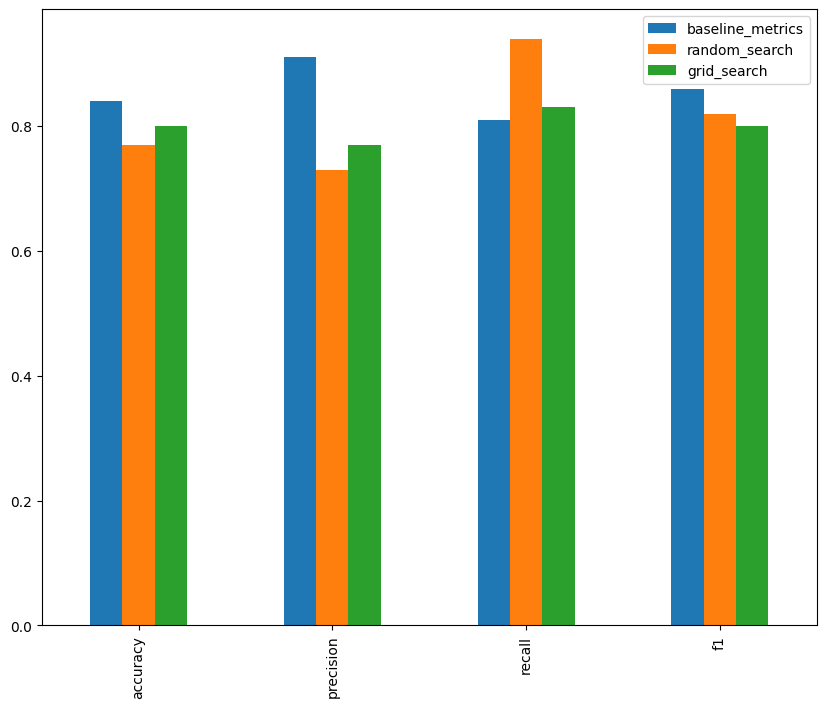

In [26]:
comparison = pd.DataFrame({"baseline_metrics": baseline_metrics,
             "random_search": rs_metrics,
             "grid_search": gs_metrics})

comparison.plot.bar(figsize=(10,8));

In [27]:
import pickle

pickle.dump(gs_model, open("Heart_Disease_Model.pkl", "wb"))

In [28]:
loaded_model=pickle.load(open("Heart_Disease_Model.pkl", "rb"))

In [29]:
loaded_model_preds = loaded_model.predict(X_test)
evaluate_preds(y_test, loaded_model_preds)

accuracy: 80.33%
Precision:  0.77
recall:  0.83
f1:  0.80


{'accuracy': 0.8, 'precision': 0.77, 'recall': 0.83, 'f1': 0.8}

### saving using joblib

In [30]:
from joblib import dump, load

dump(gs_model, filename="gs_model_joblib.joblib");

In [31]:
loaded_gs_model_joblib=load(filename="gs_model_joblib.joblib")

In [32]:
gs_model_joblib_preds=loaded_gs_model_joblib.predict(X_test)
evaluate_preds(gs_model_joblib_preds, y_test)


accuracy: 80.33%
Precision:  0.83
recall:  0.77
f1:  0.80


{'accuracy': 0.8, 'precision': 0.83, 'recall': 0.77, 'f1': 0.8}

## Sklean Pipeline
### putting different steps in a pipeline

In [33]:
car_sales = pd.read_csv("extended_car_sales.csv")
car_sales.shape

(1000, 5)

In [34]:
car_sales.dtypes

Make              object
Colour            object
Odometer (KM)    float64
Doors            float64
Price            float64
dtype: object

In [35]:
car_sales.isna().sum()

Make             49
Colour           50
Odometer (KM)    50
Doors            50
Price            50
dtype: int64

In [36]:
# fill missing values
# convert data to numbers
# build a model on the data

In [37]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV

import numpy as np
np.random.seed(23)

data = pd.read_csv("extended_car_sales.csv")
data.dropna(subset=["Price"], inplace=True)

categorical_features =["Make", "Colour"]
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")), # fill missing values with 'missing'
    ("onehot", OneHotEncoder(handle_unknown="ignore"))]) 

door_feature =["Doors"]
door_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value=4))
])

numeric_features = ["Odometer (KM)"]
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_features),
        ("door", door_transformer, door_feature),
        ("num", numeric_transformer, numeric_features)
    ])

model = Pipeline(steps=[("preprocessor", preprocessor),
                        ("model", RandomForestRegressor())])

X = data.drop("Price", axis=1)
y = data["Price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model.fit(X_train, y_train)

model.score(X_test, y_test)



0.2618296959991825

In [38]:
from sklearn.model_selection import GridSearchCV

pipe_grid= {
    "preprocessor__num__imputer__strategy": ["mean"],
    "model__n_estimators": [100, 250],
    "model__max_depth":[None, 5],
    "model__max_features": ["sqrt"],
    "model__min_samples_split":[2, 4]
}

gs_model= GridSearchCV(model, 
                       pipe_grid, 
                       cv=5, 
                       verbose=2)

gs_model.fit(X_train, y_train)


Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_split=2, model__n_estimators=100, preprocessor__num__imputer__strategy=mean; total time=   0.8s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_split=2, model__n_estimators=100, preprocessor__num__imputer__strategy=mean; total time=   0.9s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_split=2, model__n_estimators=100, preprocessor__num__imputer__strategy=mean; total time=   0.9s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_split=2, model__n_estimators=100, preprocessor__num__imputer__strategy=mean; total time=   0.9s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_split=2, model__n_estimators=100, preprocessor__num__imputer__strategy=mean; total time=   0.9s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_sample

,estimator,Pipeline(step...Regressor())])
,param_grid,"{'model__max_depth': [None, 5], 'model__max_features': ['sqrt'], 'model__min_samples_split': [2, 4], 'model__n_estimators': [100, 250], ...}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('cat', ...), ('door', ...), ...]"


In [39]:
gs_model.score(X_test, y_test)

0.308164827336754